# Previsão de Vendas com Machine Learning  
# Sales Prediction with Machine Learning

## Objetivo do Projeto | Project Objective

### Português
O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de prever vendas com base em dados históricos.  
Através da análise exploratória de dados, tratamento das variáveis e treinamento de modelos, buscamos identificar padrões que permitam estimar vendas futuras e apoiar a tomada de decisões baseada em dados.

### English
The objective of this project is to develop a Machine Learning model capable of predicting sales based on historical data.  
Through exploratory data analysis, data preprocessing, and model training, we aim to identify patterns that allow us to estimate future sales and support data-driven decision making.

In [25]:
#importando bibliotecas

#data manipulation
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
#lendo o arquivo csv
df = pd.read_csv('Advertising.csv')

#Comecando a explorar os dados
head = df.head()
shape = df.shape

print(head, shape)

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9 (200, 5)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [5]:
#verificando valores nulos
df.isnull().sum()

#Tirando a coluna 'Unnamed: 0' que é apenas um indice
df = df.drop(columns=['Unnamed: 0'])
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Análise Exploratória dos Dados
## Exploratory Data Analysis

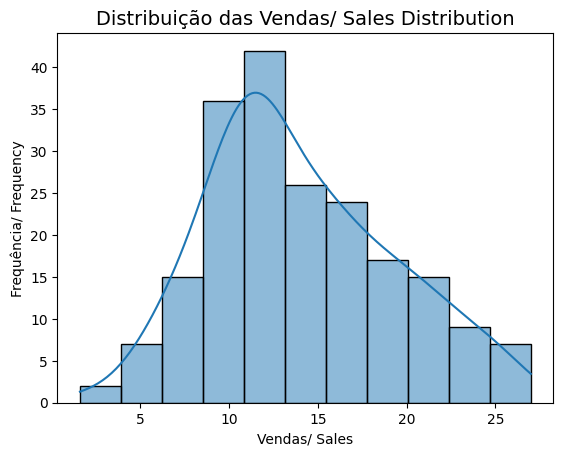

In [6]:
#visualizando a distribuição das vendas
sns.histplot(df['Sales'], kde=True)
plt.title("Distribuição das Vendas/ Sales Distribution", fontsize=14)
plt.xlabel("Vendas/ Sales")
plt.ylabel("Frequência/ Frequency")
plt.show()

## Português

A distribuição das vendas mostra que a maior concentração de valores está entre 10 e 15 unidades vendidas.
Valores muito baixos (abaixo de 5) e valores muito altos (acima de 25) são raros no conjunto de dados.

Isso indica que a maior parte das campanhas de marketing gera um volume moderado de vendas, sugerindo uma distribuição relativamente estável sem presença significativa de valores extremos.

## English

The sales distribution shows that most values are concentrated between 10 and 15 units sold.
Very low values (below 5) and very high values (above 25) appear rarely in the dataset.

This suggests that most marketing campaigns generate a moderate volume of sales, indicating a relatively stable distribution without significant extreme values.

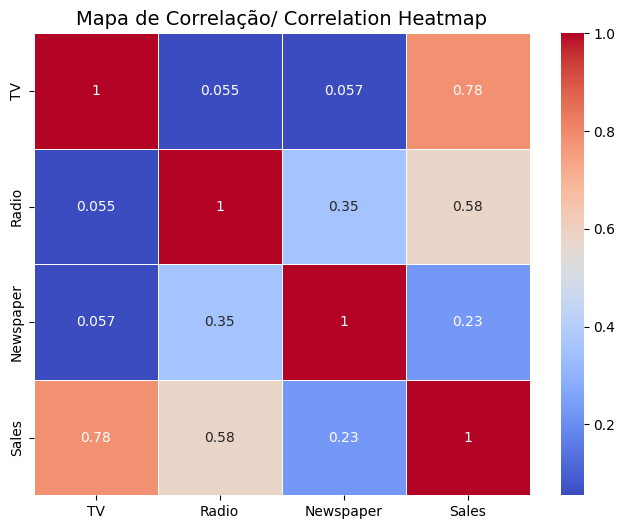

In [7]:
# verificando a correlação entre as variáveis
correlacao = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Correlação/ Correlation Heatmap", fontsize=14)
plt.show()

## Português

A análise de correlação mostra que investimentos em TV possuem a relação mais forte com as vendas (0.78), seguidos por rádio (0.58). Já anúncios em jornal apresentam correlação fraca com as vendas (0.23).

Além disso, as variáveis de marketing apresentam baixa correlação entre si, indicando que os investimentos em diferentes canais são relativamente independentes.

## English

The correlation analysis shows that TV advertising has the strongest relationship with sales (0.78), followed by radio advertising (0.58). Newspaper advertising shows only a weak correlation with sales (0.23).

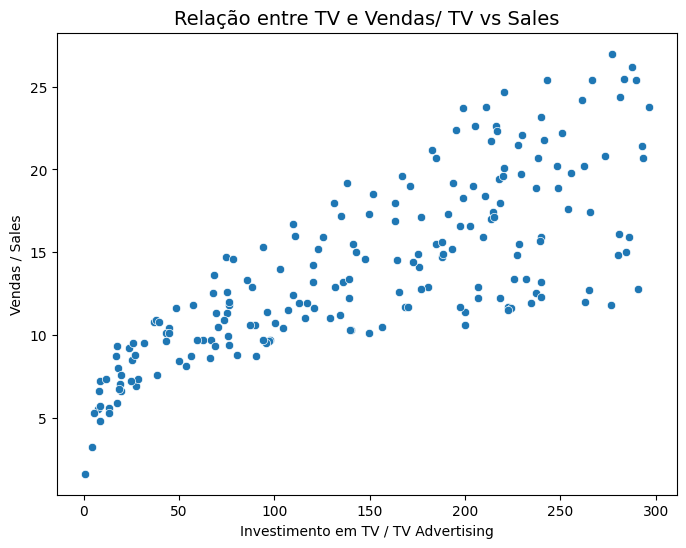

In [8]:
#visualizando a relação tv x sales
plt.figure(figsize=(8, 6))

sns.scatterplot(x=df["TV"], y=df["Sales"])

plt.title("Relação entre TV e Vendas/ TV vs Sales", fontsize=14)
plt.xlabel("Investimento em TV / TV Advertising")
plt.ylabel("Vendas / Sales")

plt.show()



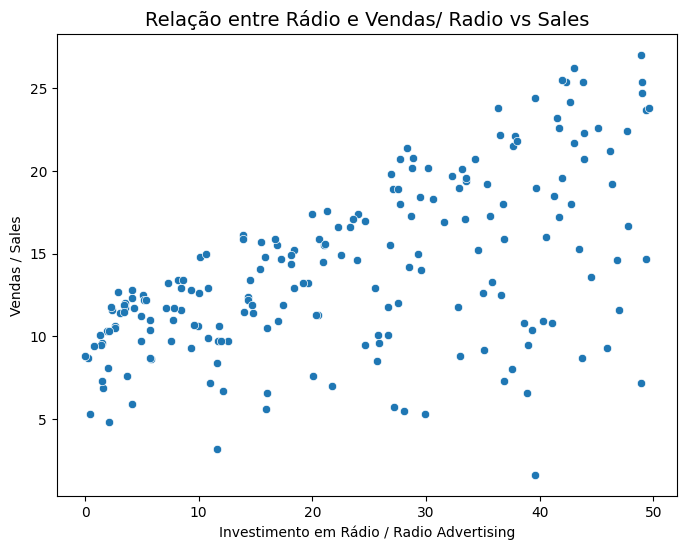

In [9]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=df["Radio"], y=df["Sales"])

plt.title("Relação entre Rádio e Vendas/ Radio vs Sales", fontsize=14)
plt.xlabel("Investimento em Rádio / Radio Advertising")
plt.ylabel("Vendas / Sales")

plt.show()

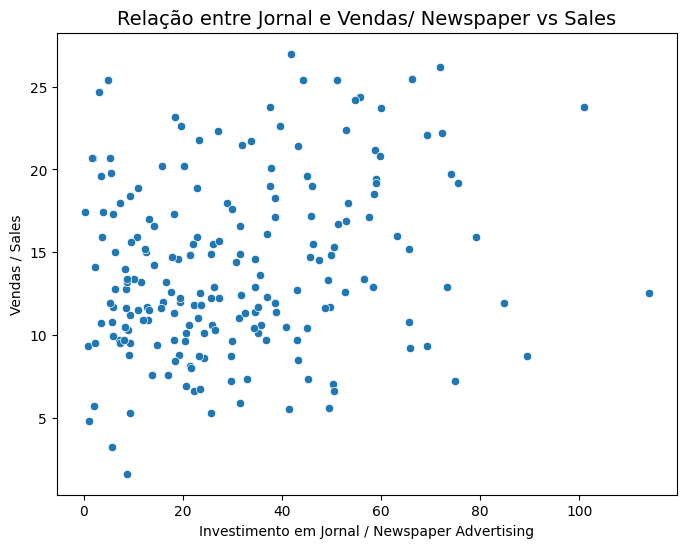

In [10]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=df["Newspaper"], y=df["Sales"])

plt.title("Relação entre Jornal e Vendas/ Newspaper vs Sales", fontsize=14)
plt.xlabel("Investimento em Jornal / Newspaper Advertising")
plt.ylabel("Vendas / Sales")

plt.show()

## Portugues 
A variável TV apresenta uma relação mais linear com Sales, indicando uma correlação mais forte.
A variável Radio também apresenta certa tendência linear, porém menos evidente.
Já Newspaper apresenta uma distribuição mais dispersa, sugerindo uma correlação fraca com as vendas.


## English
A variável TV apresenta uma relação mais linear com Sales, indicando uma correlação mais forte.
A variável Radio também apresenta certa tendência linear, porém menos evidente.
Já Newspaper apresenta uma distribuição mais dispersa, sugerindo uma correlação fraca com as vendas.

In [11]:
#Comecando a construir o modelo de regressão linear
model = LinearRegression()
x = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

In [12]:
#treinando o modelo
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
#fazendo previsões
y_pred = model.predict(x_test)

r2 = r2_score(y_test, y_pred)
print(r2)

0.899438024100912


## Português
O modelo de regressão linear foi treinado para prever as vendas com base nos investimentos em publicidade (TV, Radio e Newspaper). O modelo apresentou um R² elevado, indicando que grande parte da variação nas vendas pode ser explicada pelos investimentos em marketing.

## English 
O modelo de regressão linear foi treinado para prever as vendas com base nos investimentos em publicidade (TV, Radio e Newspaper). O modelo apresentou um R² elevado, indicando que grande parte da variação nas vendas pode ser explicada pelos investimentos em marketing.

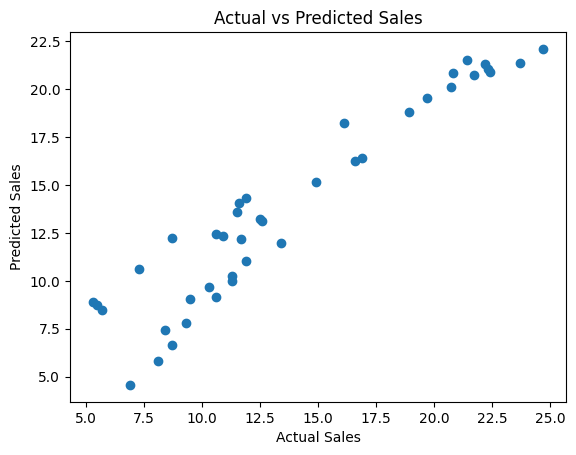

In [15]:
#visualizando o desempenho do modelo
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [16]:
#vendo os coeficientes do modelo
model.coef_

array([0.04472952, 0.18919505, 0.00276111])

## Português
Os coeficientes do modelo mostram que o rádio possui o maior impacto nas vendas, seguido pela TV. O jornal apresenta um coeficiente muito pequeno, indicando que sua influência nas vendas é praticamente irrelevante no modelo.

## English
Os coeficientes do modelo mostram que o rádio possui o maior impacto nas vendas, seguido pela TV. O jornal apresenta um coeficiente muito pequeno, indicando que sua influência nas vendas é praticamente irrelevante no modelo.

In [17]:
#Avaliando o modelo com métricas de erro
y_pred = model.predict(x_test)

print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

1.4607567168117603
3.1740973539761033


## Português
O modelo apresentou um R² de aproximadamente 0.89, indicando que cerca de 89% da variação nas vendas pode ser explicada pelos investimentos em publicidade. O erro absoluto médio (MAE) foi de aproximadamente 1.46, indicando que as previsões do modelo diferem do valor real em cerca de 1.46 unidades de vendas em média.

## English
The model achieved an R² of approximately 0.89, indicating that about 89% of the variation in sales can be explained by advertising investments. The Mean Absolute Error (MAE) was around 1.46, meaning that the model predictions differ from the actual sales values by about 1.46 units on average.

In [18]:
# Analise de Residuos
residuos = y_test - y_pred

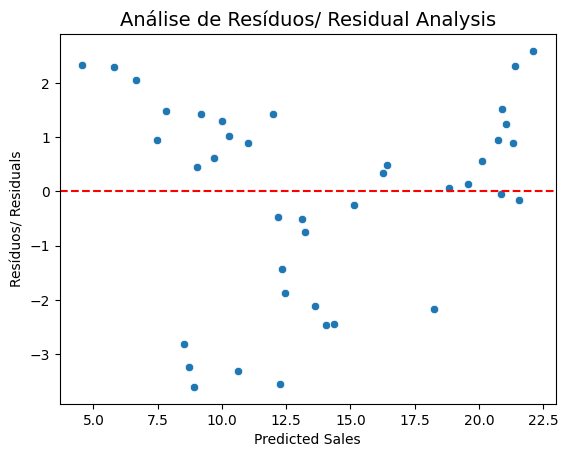

In [19]:
# Visualizando os resíduos
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Resíduos/ Residuals")
plt.title("Análise de Resíduos/ Residual Analysis", fontsize=14)

plt.show()


## Português
No gráfico de resíduos, os pontos estão distribuídos de forma relativamente aleatória em torno da linha zero. A ausência de padrões claros indica que o modelo de regressão linear está capturando bem a relação entre as variáveis. Alguns pontos aparecem muito próximos entre si, o que pode ocorrer devido a observações com valores semelhantes.

## English
In the residual plot, the points are randomly distributed around the zero line. The absence of clear patterns suggests that the linear regression model captures the relationship between the variables reasonably well. Some points appear very close to each other, which may occur due to observations with similar values.

## Português
Este projeto teve como objetivo prever vendas com base nos investimentos em três canais de marketing: TV, Rádio e Jornal.
Após a análise exploratória, ficou claro que TV possui a correlação mais forte com as vendas (0.78), seguida de Rádio (0.58). Jornal apresentou correlação fraca (0.23), o que se confirmou nos coeficientes do modelo.
O modelo de Regressão Linear foi treinado com 80% dos dados e avaliado nos 20% restantes, obtendo:

R² = 0.899 — o modelo explica aproximadamente 89% da variação nas vendas
MAE = 1.46 — erro médio de 1.46 unidades de venda
MSE = 3.17

A análise de resíduos confirmou que o modelo se ajusta bem aos dados, sem padrões que indiquem problemas.
Como principal aprendizado, Rádio tem o maior impacto por unidade investida, mesmo tendo correlação menor que TV. Isso mostra que correlação e impacto real no modelo são coisas diferentes

## English
This project aimed to predict sales based on investments across three marketing channels: TV, Radio, and Newspaper.
Exploratory analysis revealed that TV has the strongest correlation with sales (0.78), followed by Radio (0.58). Newspaper showed a weak correlation (0.23), which was confirmed by the model coefficients.
The Linear Regression model was trained on 80% of the data and evaluated on the remaining 20%, achieving:

R² = 0.899 — the model explains approximately 89% of the variation in sales
MAE = 1.46 — average prediction error of 1.46 sales units
MSE = 3.17

The residual analysis confirmed the model fits the data well, with no patterns suggesting underlying issues.
The key takeaway is that Radio has the highest impact per unit invested, even though its correlation with sales is lower than TV's. This shows that correlation and actual model impact are not the same thing.